In [479]:
import json
from pathlib import Path
from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)

In [480]:
BASE_DIR = Path("../assets/experiments/2026-03-10_21-07-34__1-4_secs")
# BASE_DIR = Path("../assets/experiments/2026-03-11_15-09-57")
# BASE_DIR = Path("../assets/experiments/2026-03-11_10-48-53__5-15_secs")

BALANCER_DIR = BASE_DIR / "baseline"
REPL_NO_ADAPT_DIR = BASE_DIR / "non_adaptive"
REPL_ADAPT_DIR = BASE_DIR / "adaptive"

print(BASE_DIR)

..\assets\experiments\2026-03-10_21-07-34__1-4_secs


In [481]:
def load_experiment(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [482]:
def extract_method(data):
    factors = data["factors"]

    balancer = factors.get("balancer")
    replication = factors.get("replication")
    adaptive = factors.get("adaptive")

    if replication:
        return f"{balancer} | {replication} | {'adaptive' if adaptive else 'no_adaptive'}"

    return f"{balancer} | no_replication"

In [483]:
def flatten_requests(data, method, group):
    rows = []

    for req in data["requests"]:

        upstream = req.get("upstream", {})
        signals = req.get("signals", {})

        sockets = upstream.get("sockets", [])
        winner = upstream.get("winner_socket")

        if sockets:
            replicas = len(sockets)
        else:
            replicas = 1

        rows.append({
            "method": method,
            "group": group,

            "req_id": req["req_id"],
            "endpoint": req["endpoint"],

            "latency_ms": req["latency_ms"],
            "status": req["status"],
            "ok": req["ok"],

            "winner_socket": winner,
            "backend_port": signals.get("port"),

            "replicas": replicas,

            "cpu_util": signals.get("cpu_util"),
            "mem_util": signals.get("mem_util"),
            "cpu_burn": signals.get("cpu_burn"),
            "mem_burn": signals.get("mem_burn"),
        })

    return pd.DataFrame(rows)

In [484]:
def load_folder(folder, group):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        method = extract_method(data)

        df = flatten_requests(data, method, group)

        dfs.append(df)

    return dfs


dfs = []

dfs += load_folder(BALANCER_DIR, "balancer_only")
dfs += load_folder(REPL_NO_ADAPT_DIR, "replication_no_adaptive")
dfs += load_folder(REPL_ADAPT_DIR, "replication_adaptive")

df = pd.concat(dfs, ignore_index=True)

df.head()

,method,group,req_id,endpoint,latency_ms,status,ok,winner_socket,backend_port,replicas,cpu_util,mem_util,cpu_burn,mem_burn
0,airm | no_replication,balancer_only,req-0,cpu?seconds=2,5498.5829,200,True,None,8001.0,1,28.9,19.8,True,None
1,airm | no_replication,balancer_only,req-1,cpu?seconds=2,4634.4987,200,True,None,8001.0,1,0.0,19.4,True,None
2,airm | no_replication,balancer_only,req-2,mem?seconds=2&mb=75,2151.8417,200,True,None,8005.0,1,26.1,17.2,None,True
3,airm | no_replication,balancer_only,req-3,cpu?seconds=4,4091.4091,200,True,None,8005.0,1,25.2,19.1,True,None
4,airm | no_replication,balancer_only,req-4,cpu?seconds=3,3130.9704,200,True,None,8001.0,1,26.8,18.5,True,None


In [485]:
def p50(x):
    return np.percentile(x, 50)


def p95(x):
    return np.percentile(x, 95)


def p99(x):
    return np.percentile(x, 99)

# Latency

In [486]:
latency_stats = (
    df
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p50=p50,
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

latency_stats

,mean,p50,p95,p99
method,,,,
electre | speculative | adaptive,2710.249344,2577.57830,4551.887315,5242.681832
topsis | hedged | adaptive,2731.448558,2609.49830,4854.570520,5225.841436
topsis | speculative | adaptive,2741.461105,2616.59310,4925.768640,5239.457292
airm | speculative | adaptive,2767.426784,2595.83710,4721.362470,5243.723620
airm | hedged | adaptive,2796.822224,2623.26005,5100.871170,5238.695951
electre | hedged | adaptive,2800.456781,2622.65560,5209.438110,5251.694839
topsis | speculative | no_adaptive,2890.024800,2623.32455,5206.376700,5230.171634
airm | speculative | no_adaptive,2903.728101,2629.37565,5156.518600,5233.675204
airm | hedged | no_adaptive,2916.046089,2630.60690,5218.509285,5239.462950


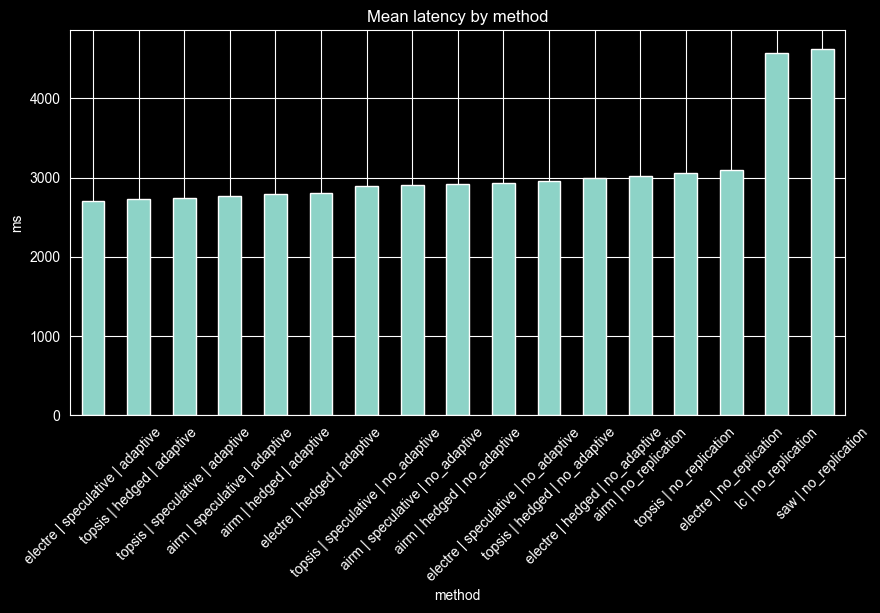

In [487]:
latency_stats["mean"].plot(kind="bar")

plt.title("Mean latency by method")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

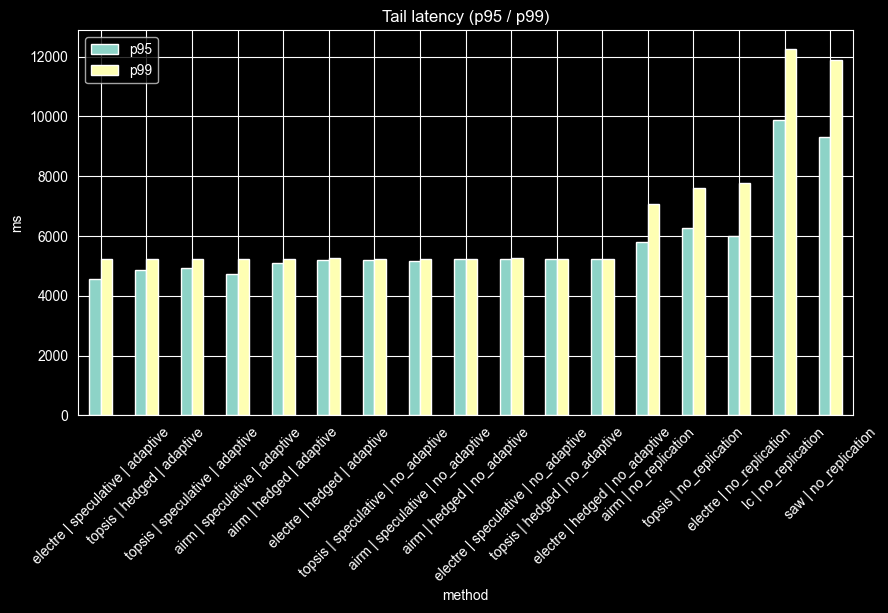

In [488]:
latency_stats[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency (p95 / p99)")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

# WA

In [489]:
wa_stats = (
    df
    .groupby("method")["replicas"]
    .agg(
        mean="mean",
        p95=p95,
        max="max"
    )
    .sort_values("mean")
)

wa_stats

,mean,p95,max
method,,,
airm | no_replication,1.000,1.0,1
electre | no_replication,1.000,1.0,1
lc | no_replication,1.000,1.0,1
saw | no_replication,1.000,1.0,1
topsis | no_replication,1.000,1.0,1
topsis | hedged | adaptive,1.493,3.0,3
electre | speculative | adaptive,1.498,3.0,3
topsis | speculative | adaptive,1.500,3.0,3
electre | hedged | adaptive,1.535,3.0,3


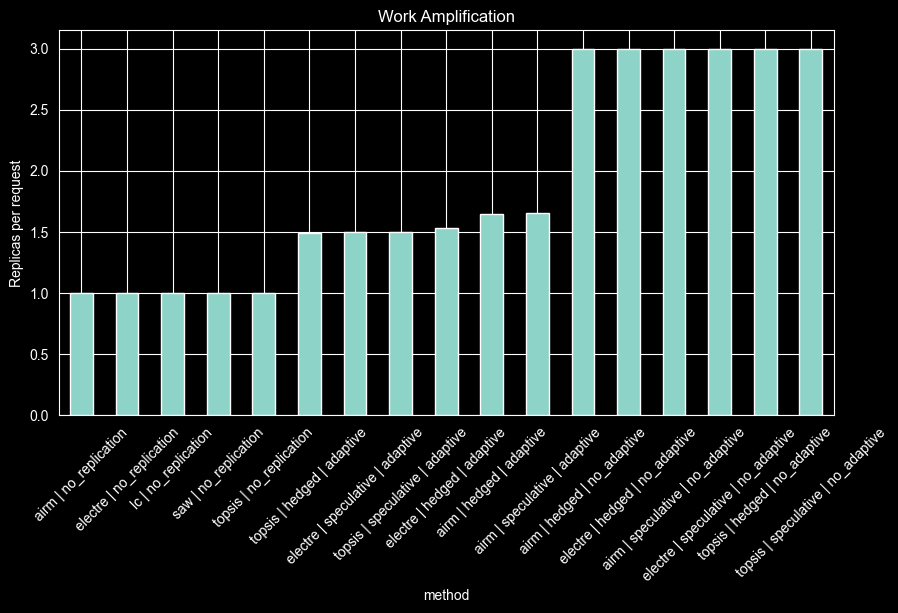

In [490]:
wa_stats["mean"].plot(kind="bar")

plt.title("Work Amplification")
plt.ylabel("Replicas per request")

plt.xticks(rotation=45)

plt.show()

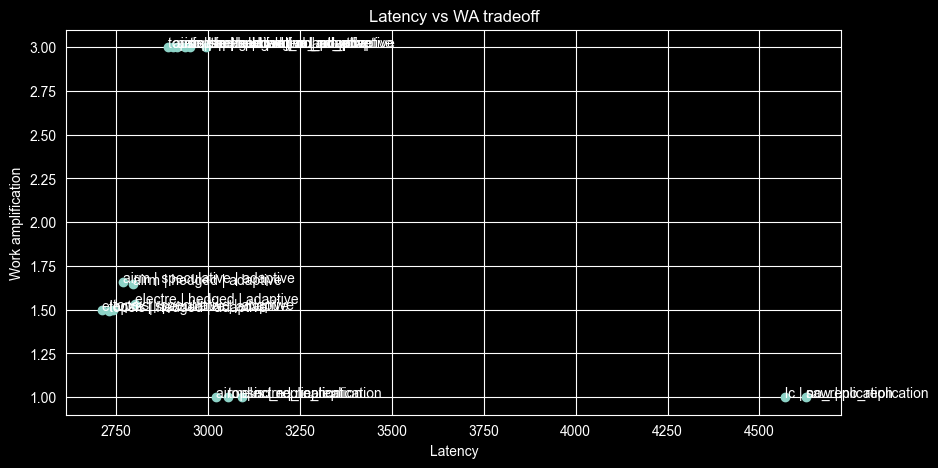

In [491]:
tradeoff = latency_stats.merge(
    wa_stats,
    left_index=True,
    right_index=True
)

plt.scatter(tradeoff["mean_x"], tradeoff["mean_y"])

for name, row in tradeoff.iterrows():
    plt.text(row["mean_x"], row["mean_y"], name)

plt.xlabel("Latency")
plt.ylabel("Work amplification")

plt.title("Latency vs WA tradeoff")

plt.show()

# CPU / MEM

In [492]:
socket_dist = (
    df
    .groupby(["method", "winner_socket"])
    .size()
    .reset_index(name="count")
)

socket_dist.head()

,method,winner_socket,count
0,airm | hedged | adaptive,,354
1,airm | hedged | adaptive,192.168.68.50_GQW_8001,17
2,airm | hedged | adaptive,192.168.68.50_GQW_8002,5
3,airm | hedged | adaptive,192.168.68.50_GQW_8003,13
4,airm | hedged | adaptive,192.168.68.50_GQW_8004,25


In [493]:
balance = (
    socket_dist
    .groupby("method")["count"]
    .agg(
        mean="mean",
        std="std"
    )
)

balance["cv"] = balance["std"] / balance["mean"]

balance.sort_values("cv")

,mean,std,cv
method,,,
electre | speculative | adaptive,26.315789,45.981844,1.747310
airm | speculative | adaptive,26.315789,55.147520,2.095606
electre | hedged | adaptive,26.315789,55.871041,2.123100
topsis | hedged | adaptive,23.809524,52.252781,2.194617
topsis | speculative | adaptive,25.641026,57.111842,2.227362
airm | hedged | adaptive,23.255814,53.619956,2.305658
airm | speculative | no_adaptive,23.255814,81.787498,3.516862
topsis | speculative | no_adaptive,23.809524,93.911541,3.944285
electre | speculative | no_adaptive,23.255814,95.318787,4.098708


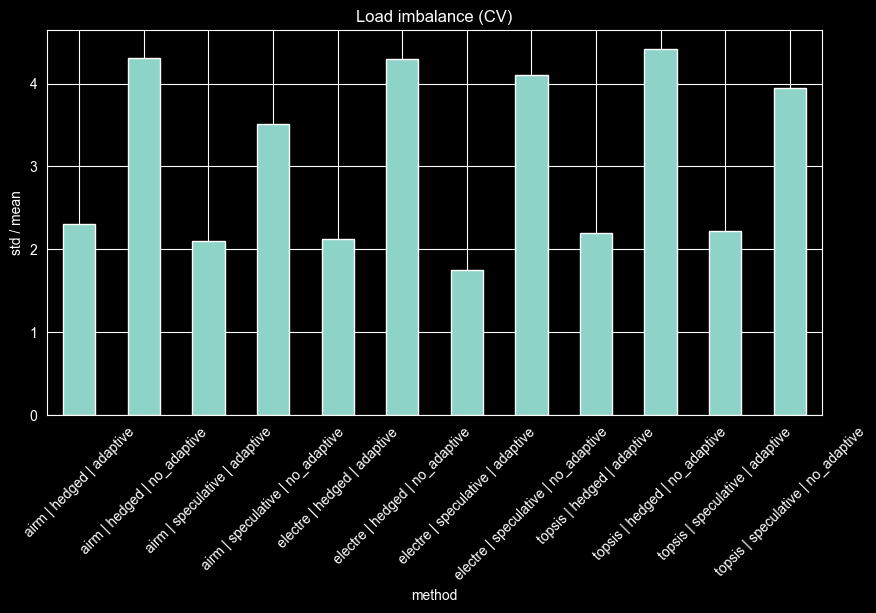

In [494]:
balance["cv"].plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

In [495]:
lat_by_group = (
    df
    .groupby("group")["latency_ms"]
    .agg(
        mean="mean",
        p95=p95,
        p99=p99
    )
)

lat_by_group

,mean,p95,p99
group,,,
balancer_only,3672.833473,8018.825395,11476.199152
replication_adaptive,2757.977466,4963.067415,5240.622156
replication_no_adaptive,2931.947933,5218.469850,5240.984332


In [496]:
baseline = lat_by_group.loc["balancer_only"]
rep_no = lat_by_group.loc["replication_no_adaptive"]
rep_ad = lat_by_group.loc["replication_adaptive"]

improvement = (baseline - rep_no) / baseline * 100

print("Replication improvement:")
print(improvement)

Replication improvement:
mean    20.172043
p95     34.922266
p99     54.331706
dtype: float64


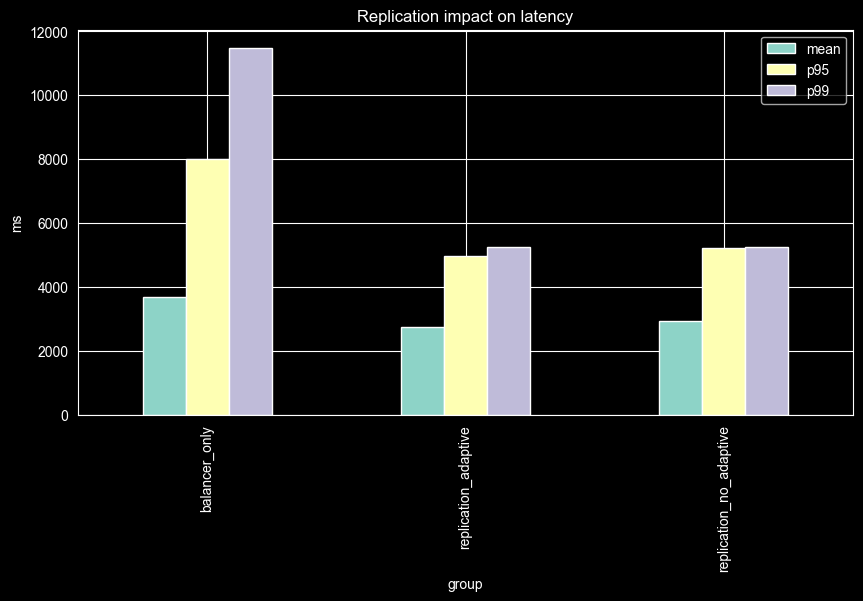

In [497]:
lat_by_group.plot(kind="bar")

plt.title("Replication impact on latency")

plt.ylabel("ms")

plt.show()

# Выгода адаптивности

In [498]:
wa_group = (
    df
    .groupby("group")["replicas"]
    .mean()
)

wa_group

group
balancer_only              1.000
replication_adaptive       1.555
replication_no_adaptive    3.000
Name: replicas, dtype: float64

In [499]:
adaptive_gain = (
                        (wa_group["replication_no_adaptive"]
                         - wa_group["replication_adaptive"])

                        / wa_group["replication_no_adaptive"]

                ) * 100

print("Adaptive WA reduction:", adaptive_gain)

Adaptive WA reduction: 48.16666666666667


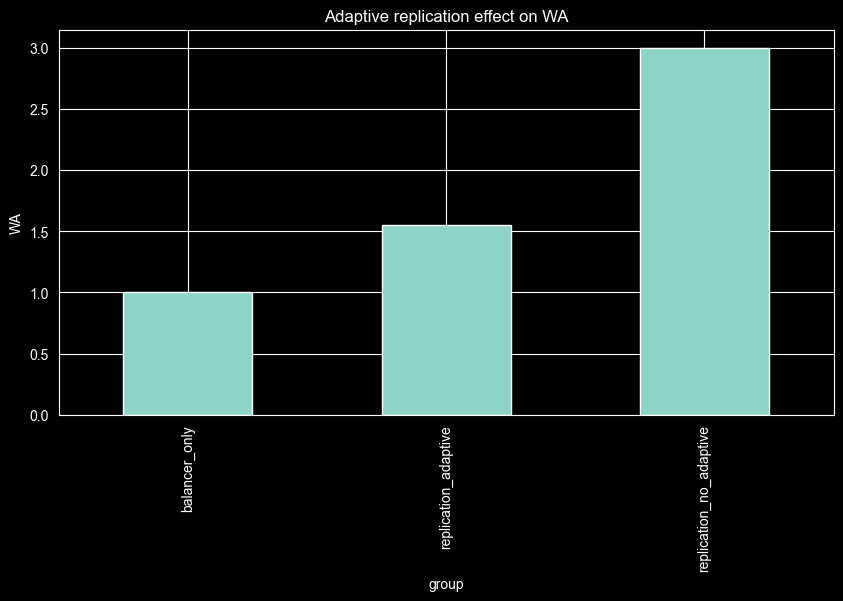

In [500]:
wa_group.plot(kind="bar")

plt.title("Adaptive replication effect on WA")

plt.ylabel("WA")

plt.show()

# CPU vs MEM Latency

In [446]:
df["is_cpu"] = df["endpoint"].str.startswith("cpu")

lat_cpu_mem = (

    df
    .groupby(["method","is_cpu"])["latency_ms"]
    .mean()
    .unstack()
)

lat_cpu_mem

is_cpu,False,True
method,,
airm | hedged | adaptive,2907.820359,2694.362407
airm | hedged | no_adaptive,2925.542283,2906.775102
airm | no_replication,3305.327540,2721.081064
airm | speculative | adaptive,2835.319818,2690.866554
airm | speculative | no_adaptive,3018.246022,2790.576198
electre | hedged | adaptive,2925.959250,2685.533064
electre | hedged | no_adaptive,3115.533673,2875.510967
electre | no_replication,3335.521533,2855.658973
electre | speculative | adaptive,2786.451435,2630.936964


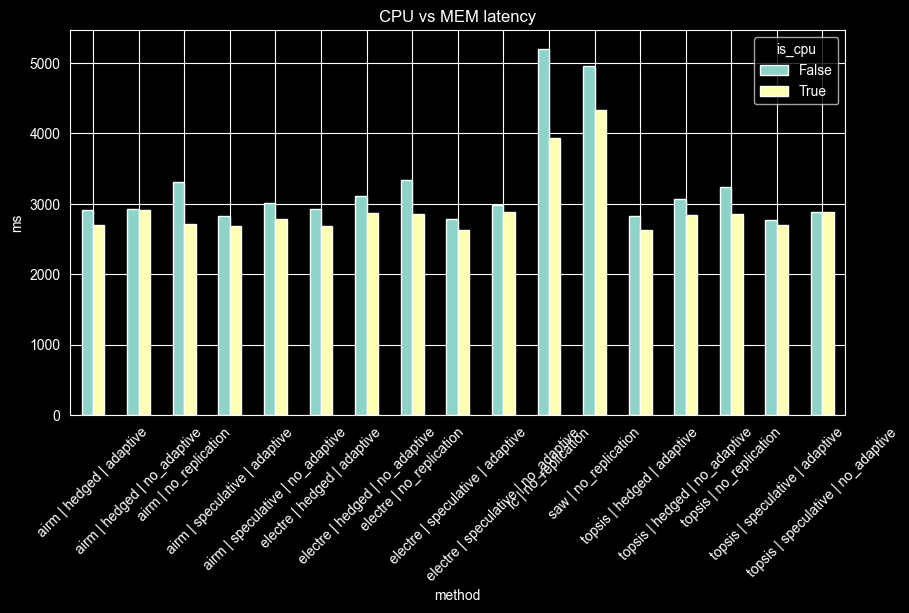

In [447]:
lat_cpu_mem.plot(kind="bar")

plt.title("CPU vs MEM latency")

plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

In [448]:
best_mean = latency_stats["mean"].idxmin()
best_p95 = latency_stats["p95"].idxmin()
best_wa = wa_stats["mean"].idxmin()

print("Best mean latency:", best_mean)
print("Best p95 latency:", best_p95)
print("Best WA:", best_wa)

Best mean latency: electre | speculative | adaptive
Best p95 latency: electre | speculative | adaptive
Best WA: airm | no_replication


# Сравнение с HAProxy

In [501]:
HAPROXY_DIR = Path("../assets/experiments/haproxy__1-4_secs")

def load_haproxy(folder):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        name = file.stem.replace("haproxy_", "")
        method = f"haproxy | {name}"

        rows = []

        for req in data["requests"]:

            upstream = req.get("upstream", {})
            signals = req.get("signals", {})

            winner = upstream.get("winner_socket")

            rows.append({
                "method": method,
                "group": "haproxy",

                "req_id": req["req_id"],
                "endpoint": req["endpoint"],

                "latency_ms": req["latency_ms"],
                "status": req["status"],
                "ok": req["ok"],

                "winner_socket": winner,
                "replicas": 1,

                "cpu_util": signals.get("cpu_util"),
                "mem_util": signals.get("mem_util"),
                "cpu_burn": signals.get("cpu_burn"),
                "mem_burn": signals.get("mem_burn"),
            })

        dfs.append(pd.DataFrame(rows))

    return dfs


haproxy_dfs = load_haproxy(HAPROXY_DIR)

df_haproxy = pd.concat(haproxy_dfs, ignore_index=True)

df_haproxy.head()

,method,group,req_id,endpoint,latency_ms,status,ok,winner_socket,replicas,cpu_util,mem_util,cpu_burn,mem_burn
0,haproxy | leastconn,haproxy,req-0,mem?seconds=1&mb=75,1071.7843,200,True,n1_p8001,1,15.3,17.3,None,True
1,haproxy | leastconn,haproxy,req-1,mem?seconds=2&mb=75,2078.7392,200,True,n1_p8002,1,31.4,18.0,None,True
2,haproxy | leastconn,haproxy,req-2,cpu?seconds=3,3017.2059,200,True,n2_p8001,1,33.9,18.0,True,None
3,haproxy | leastconn,haproxy,req-3,cpu?seconds=1,1081.3741,200,True,n2_p8006,1,17.8,17.3,True,None
4,haproxy | leastconn,haproxy,req-4,cpu?seconds=3,3051.2834,200,True,n3_p8001,1,34.1,18.2,True,None


In [502]:
df_all = pd.concat([df, df_haproxy], ignore_index=True)
df_all["backend"] = df_all["backend_port"].fillna(df_all["winner_socket"])
df_all.head()

,method,group,req_id,endpoint,latency_ms,status,ok,winner_socket,backend_port,replicas,cpu_util,mem_util,cpu_burn,mem_burn,backend
0,airm | no_replication,balancer_only,req-0,cpu?seconds=2,5498.5829,200,True,None,8001.0,1,28.9,19.8,True,None,8001.0
1,airm | no_replication,balancer_only,req-1,cpu?seconds=2,4634.4987,200,True,None,8001.0,1,0.0,19.4,True,None,8001.0
2,airm | no_replication,balancer_only,req-2,mem?seconds=2&mb=75,2151.8417,200,True,None,8005.0,1,26.1,17.2,None,True,8005.0
3,airm | no_replication,balancer_only,req-3,cpu?seconds=4,4091.4091,200,True,None,8005.0,1,25.2,19.1,True,None,8005.0
4,airm | no_replication,balancer_only,req-4,cpu?seconds=3,3130.9704,200,True,None,8001.0,1,26.8,18.5,True,None,8001.0


In [516]:
df_balancing = df_all[
    df_all["group"].isin(["balancer_only", "haproxy"])
].copy()

df_balancing["method"].unique()

<StringArray>
[   'airm | no_replication', 'electre | no_replication',
      'lc | no_replication',     'saw | no_replication',
  'topsis | no_replication',      'haproxy | leastconn',
         'haproxy | random',     'haproxy | roundrobin']
Length: 8, dtype: str

In [531]:
df_balancing_only = df_all[
    df_all["group"].isin(["balancer_only", "haproxy"])
].copy()

print("Methods in df_balancing_only:")
print(sorted(df_balancing_only["method"].unique()))

df_balancing_only["backend"] = (
    df_balancing_only["backend_port"]
    .astype("string")
    .fillna(df_balancing_only["winner_socket"])
)

Methods in df_balancing_only:
['airm | no_replication', 'electre | no_replication', 'haproxy | leastconn', 'haproxy | random', 'haproxy | roundrobin', 'lc | no_replication', 'saw | no_replication', 'topsis | no_replication']


## Сравнение HAProxy алгоритмов

In [532]:
lat_compare = (
    df_balancing
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

lat_compare

,mean,p95,p99
method,,,
airm | no_replication,3020.799506,5802.408035,7075.433052
topsis | no_replication,3054.260751,6267.763535,7602.709308
electre | no_replication,3091.751353,5992.824380,7755.716722
lc | no_replication,4570.275612,9875.137820,12262.980188
saw | no_replication,4627.080143,9321.799420,11896.924744
haproxy | random,5622.297128,16970.215820,19414.030993
haproxy | leastconn,5709.932831,16793.308155,19427.507929
haproxy | roundrobin,5985.620070,19373.330580,19453.431726


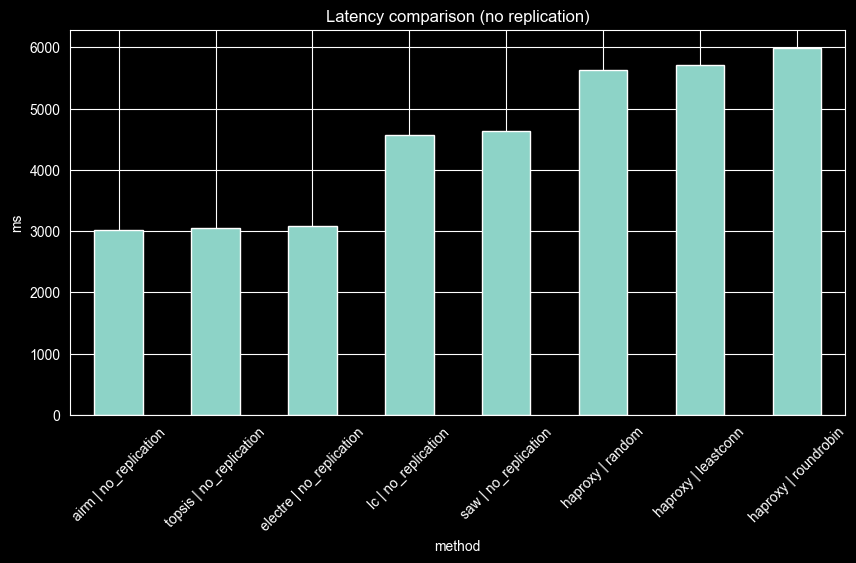

In [533]:
lat_compare["mean"].plot(kind="bar")

plt.title("Latency comparison (no replication)")
plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

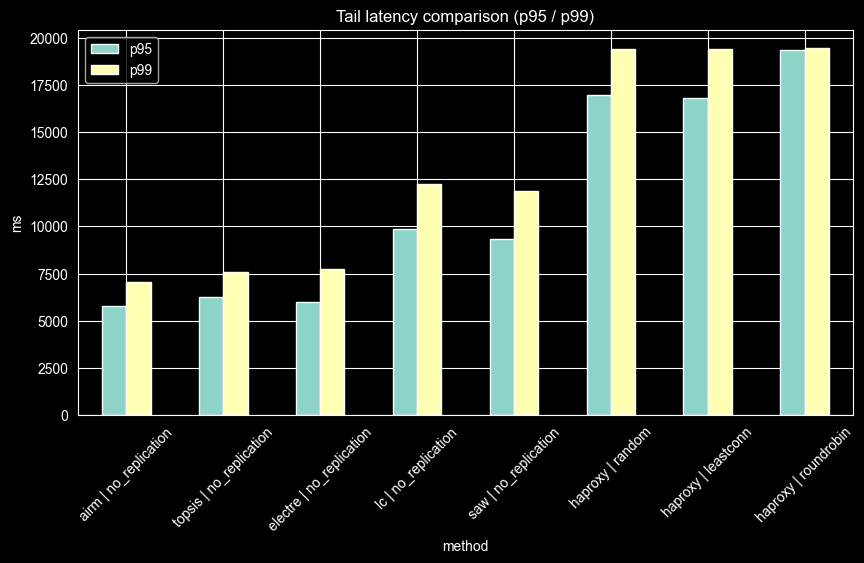

In [534]:
lat_compare[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency comparison (p95 / p99)")
plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

## Балансировка нагрузки HAProxy

In [536]:
socket_counts_balancing = (
    df_balancing_only
    .groupby(["method", "backend"])
    .size()
    .reset_index(name="count")
)

print("Methods in socket_counts_balancing:")
print(sorted(socket_counts_balancing["method"].unique()))

Methods in socket_counts_balancing:
['airm | no_replication', 'electre | no_replication', 'haproxy | leastconn', 'haproxy | random', 'haproxy | roundrobin', 'lc | no_replication', 'saw | no_replication', 'topsis | no_replication']


<Figure size 1200x600 with 0 Axes>

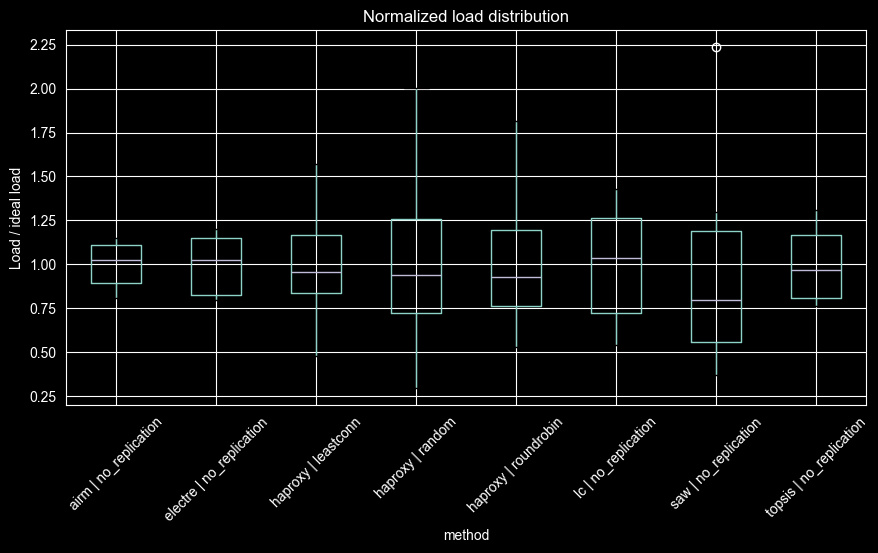

In [538]:
socket_counts_balancing["normalized"] = (
        socket_counts_balancing["count"] /
        socket_counts_balancing.groupby("method")["count"].transform("mean")
)

plt.figure(figsize=(12,6))

socket_counts_balancing.boxplot(
    column="normalized",
    by="method",
    rot=45
)

plt.title("Normalized load distribution")
plt.suptitle("")
plt.ylabel("Load / ideal load")

plt.show()

In [508]:
imbalance = socket_counts.groupby("method")["count"].agg(
    mean="mean",
    std="std"
)

imbalance["cv"] = imbalance["std"] / imbalance["mean"]

imbalance.sort_values("cv")

,mean,std,cv
method,,,
haproxy | leastconn,22.928571,5.452200,0.237791
haproxy | roundrobin,22.595238,7.022818,0.310810
haproxy | random,23.476190,8.760327,0.373158


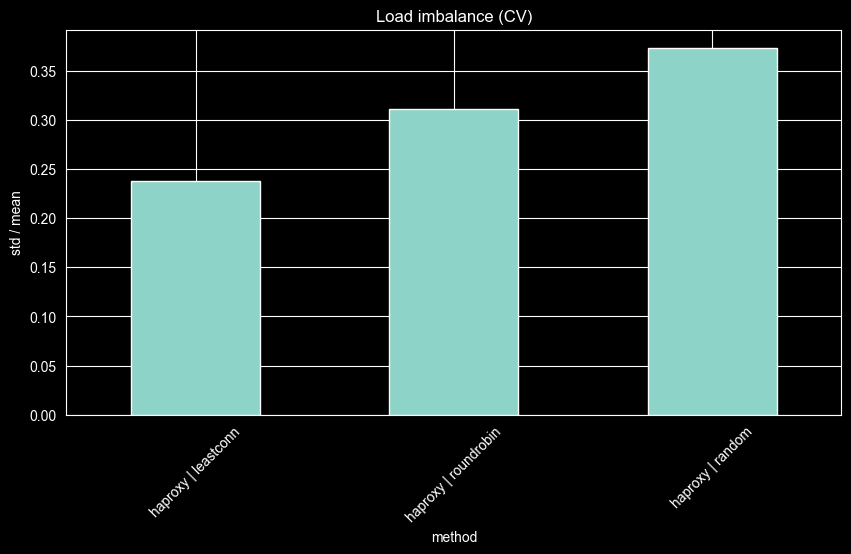

In [509]:
imbalance["cv"].sort_values().plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

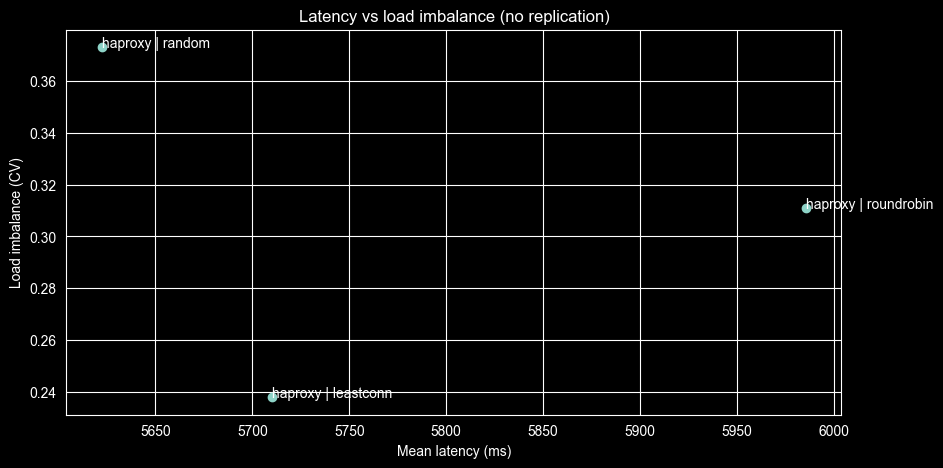

In [510]:
lat_mean = (
    df_balancing
    .groupby("method")["latency_ms"]
    .mean()
)

tradeoff = pd.concat([lat_mean, imbalance["cv"]], axis=1)

plt.scatter(tradeoff["latency_ms"], tradeoff["cv"])

for name, row in tradeoff.iterrows():
    plt.text(row["latency_ms"], row["cv"], name)

plt.xlabel("Mean latency (ms)")
plt.ylabel("Load imbalance (CV)")

plt.title("Latency vs load imbalance (no replication)")

plt.show()

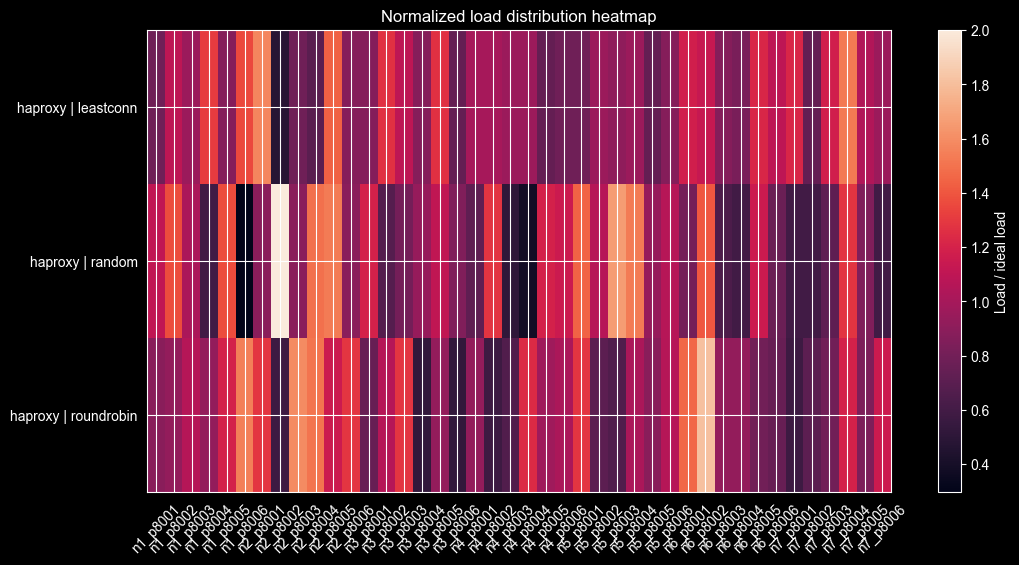

In [511]:
heat = (
    socket_counts
    .groupby(["method", "winner_socket"])["normalized"]
    .mean()
    .reset_index()
)

pivot = heat.pivot(
    index="method",
    columns="winner_socket",
    values="normalized"
)

plt.figure(figsize=(12,6))

plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Load / ideal load")

plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)

plt.title("Normalized load distribution heatmap")

plt.show()

## Числовые сравнения

In [512]:
lat_stats = (
    df_all
    .groupby("method")["latency_ms"]
    .agg(mean="mean", p95=p95, p99=p99)
)

my_algorithms = lat_stats[
    lat_stats.index.str.contains("no_replication")
]

haproxy_algorithms = lat_stats[
    lat_stats.index.str.contains("haproxy")
]

best_my = my_algorithms.sort_values("mean").iloc[0]
best_haproxy = haproxy_algorithms.sort_values("mean").iloc[0]

best_my_name = my_algorithms.sort_values("mean").index[0]
best_haproxy_name = haproxy_algorithms.sort_values("mean").index[0]

print("Best my algorithm:", best_my_name)
print("Best haproxy algorithm:", best_haproxy_name)

Best my algorithm: airm | no_replication
Best haproxy algorithm: haproxy | random


In [513]:
mean_gain = (best_haproxy["mean"] - best_my["mean"]) / best_haproxy["mean"] * 100
p95_gain = (best_haproxy["p95"] - best_my["p95"]) / best_haproxy["p95"] * 100
p99_gain = (best_haproxy["p99"] - best_my["p99"]) / best_haproxy["p99"] * 100

print(f"Mean latency improvement: {mean_gain:.2f}%")
print(f"P95 latency improvement: {p95_gain:.2f}%")
print(f"P99 latency improvement: {p99_gain:.2f}%")

Mean latency improvement: 46.27%
P95 latency improvement: 65.81%
P99 latency improvement: 63.56%


In [514]:
imbalance = socket_counts.groupby("method")["count"].agg(mean="mean", std="std")
imbalance["cv"] = imbalance["std"] / imbalance["mean"]

best_my_cv = imbalance.loc[best_my_name, "cv"]
best_haproxy_cv = imbalance.loc[best_haproxy_name, "cv"]

cv_gain = (best_haproxy_cv - best_my_cv) / best_haproxy_cv * 100

print(f"Load balance improvement: {cv_gain:.2f}%")

KeyError: 'airm | no_replication'

# Сравнение ошибок

In [463]:
error_stats = (
    df
    .groupby("method")["ok"]
    .agg(
        total="count",
        success="sum"
    )
)

error_stats["errors"] = error_stats["total"] - error_stats["success"]
error_stats["error_rate"] = error_stats["errors"] / error_stats["total"]

error_stats.sort_values("error_rate", ascending=False)

,total,success,errors,error_rate
method,,,,
topsis | hedged | no_adaptive,1000,311,689,0.689
airm | hedged | no_adaptive,1000,335,665,0.665
electre | hedged | no_adaptive,1000,337,663,0.663
electre | speculative | no_adaptive,1000,367,633,0.633
topsis | speculative | no_adaptive,1000,383,617,0.617
airm | speculative | no_adaptive,1000,454,546,0.546
topsis | speculative | adaptive,1000,641,359,0.359
airm | hedged | adaptive,1000,646,354,0.354
electre | hedged | adaptive,1000,655,345,0.345


In [464]:
error_by_group = (
    df
    .groupby("group")["ok"]
    .agg(
        total="count",
        success="sum"
    )
)

error_by_group["errors"] = error_by_group["total"] - error_by_group["success"]
error_by_group["error_rate"] = error_by_group["errors"] / error_by_group["total"]

error_by_group

,total,success,errors,error_rate
group,,,,
balancer_only,5000,4993,7,0.001400
replication_adaptive,6000,3991,2009,0.334833
replication_no_adaptive,6000,2187,3813,0.635500


In [465]:
baseline_err = error_by_group.loc["balancer_only", "error_rate"]
rep_no_err = error_by_group.loc["replication_no_adaptive", "error_rate"]
rep_ad_err = error_by_group.loc["replication_adaptive", "error_rate"]

replication_gain = (baseline_err - rep_no_err) / baseline_err * 100
adaptive_gain = (rep_no_err - rep_ad_err) / rep_no_err * 100

print(f"Replication error reduction: {replication_gain:.2f}%")
print(f"Adaptive replication improvement: {adaptive_gain:.2f}%")

Replication error reduction: -45292.86%
Adaptive replication improvement: 47.31%


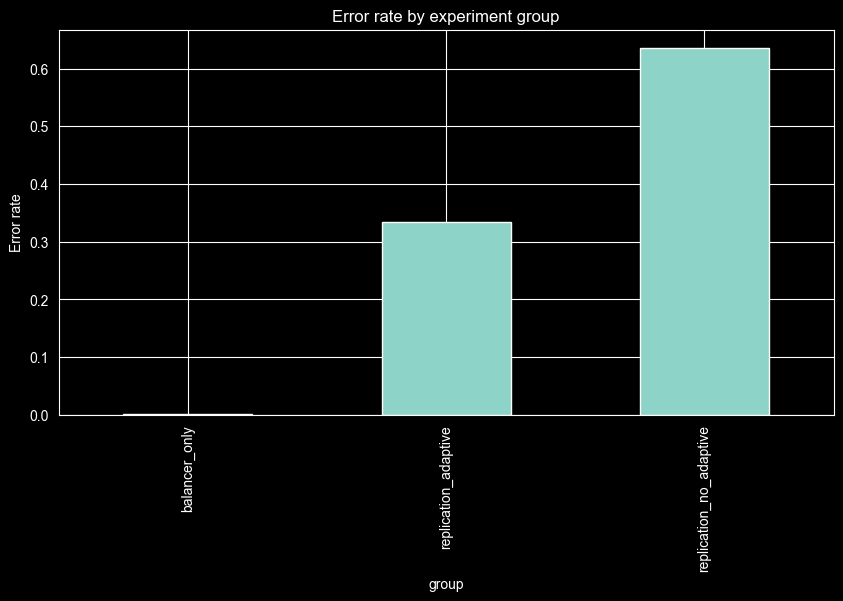

In [466]:
error_by_group["error_rate"].plot(kind="bar")

plt.title("Error rate by experiment group")
plt.ylabel("Error rate")

plt.show()